In [12]:
from src.utils.paths import PROJECT_ROOT, DATA_DIR, EXTERNAL_DATA_DIR, IMAGERY_ROOT, RAW_DATA_DIR

In [1]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [13]:
import os
# 1. Force TensorFlow to use the legacy Keras 2 engine for this script
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf

# 2. Define your paths
model_folder = "/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/raw/EfficientNetV2S Trained Model Weights/effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141"

# We use .h5 here because Keras 2 excels at saving it, and Keras 3 excels at reading it.
output_filepath = "/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/raw/EfficientNetV2S Trained Model Weights/plos_weights.h5"

print(f"Loading legacy model from: {model_folder}")

try:
    # 3. Load the model using Keras 2
    model = tf.keras.models.load_model(model_folder)
    print("Legacy model loaded successfully!")
    
    # 4. Save it as an HDF5 file
    model.save(output_filepath)
    print(f"Success! Bridge model saved to: {output_filepath}")

except Exception as e:
    print(f"An error occurred during conversion:\n{e}")

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-s (Function  (None, 4, 4, 1280)        20332440  
 al)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 20480)             0         
                                                                 
 predictions (Dense)         (None, 1)                 20481     
                                                                 
Total params: 20352921 (77.64 MB)
Trainable params: 20199049 (77.05 MB)
Non-trainable params: 153872 (601.06 KB)
_________________________________________________________________


In [ ]:
import pandas as pd

df = pd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/val_datasets/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_val_dataframe.feather")
df

,index,GEOID,var,type,geometry,dataset_2016,dataset_2018,dataset_2020,dataset_2022,dataset_2024
0,125326,36081010400,-0.520629,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,nyc_2024.zarr
1,70303,36085017016,0.566646,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,None
2,95815,36047088200,-1.052836,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\t\x00\x...,nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,nyc_2024.zarr
3,274472,36081100801,0.630120,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,nyc_2024.zarr
4,272107,36081052200,0.022199,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,nyc_2024.zarr
...,...,...,...,...,...,...,...,...,...,...
21920,293137,36047046202,0.227164,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\t\x00\x...",nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,nyc_2024.zarr
21921,69804,36081033405,0.456766,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,nyc_2024.zarr
21922,258693,36081066301,0.756631,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...,nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,nyc_2024.zarr
21923,228689,36085018901,0.977045,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr,nyc_2018.zarr,nyc_2020.zarr,nyc_2022.zarr,None


In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from src import build_dataset
gdf = build_dataset.load_income_dataset()
gdf

,capture_da,boroname,index_righ,GEOID,STATE,COUNTY,TRACT,NAME,CNTY_FIPS,avg_hh_inc,geometry,var
0,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1067053.173 209139.295, 1067044.762 ...",0.903605
1,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066993.434 211949.564, 1067030.554 ...",0.903605
2,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066744.615 209584.918, 1066783.937 ...",0.903605
3,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066671.441 209426.912, 1066706.044 ...",0.903605
4,None,Queens,74995,36081157903,36,081,157903,Census Tract 1579.03,36081,104135,"POLYGON ((1066621.379 208092.188, 1066602.7 20...",0.317018
...,...,...,...,...,...,...,...,...,...,...,...,...
457302,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914278.373 123196.517, 914236.906 12...",1.036937
457303,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914230.566 124269.59, 914264.523 124...",1.036937
457304,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914203.412 124013.548, 914200.86 123...",1.036937
457305,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((913923.046 124090.499, 913924.229 12...",1.036937


<Axes: ylabel='Frequency'>

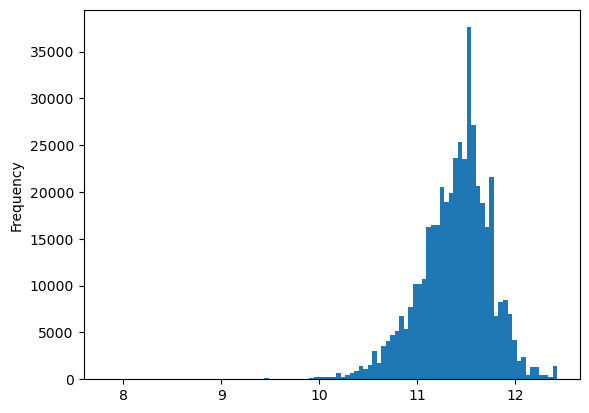

In [ ]:
import numpy as np
gdf["avg_hh_inc"].apply(lambda x: np.log(x)).plot.hist(bins=100)

In [ ]:
df

In [ ]:
import os
os.listdir()

['effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_0.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_10.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_100.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1000.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1001.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1002.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1003.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1004.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1005.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1006.keras',
 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-

In [ ]:
import re
import shutil
# 1. Define your paths
source_folder = r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling"  # Change this to the path where your files are
target_folder = r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/archive"

# Create the target folder if it doesn't exist
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

# 2. Get all files in the directory
files = os.listdir(source_folder)

# 3. Regular expression to find the number just before '.keras'
# It looks for digits (\d+) followed by '.keras' at the end of the string ($)
pattern = re.compile(r'_(\d+)\.keras$')

moved_count = 0

for filename in files:
    match = pattern.search(filename)
    
    if match:
        # Extract the number and convert to integer
        file_index = int(match.group(1))
        
        # Check if it is NOT a multiple of 5
        if file_index % 5 != 0:
            source_path = os.path.join(source_folder, filename)
            target_path = os.path.join(target_folder, filename)
            print(f"Moving '{filename}' to '{target_folder}'")
            # Move the file
            shutil.move(source_path, target_path)
            moved_count += 1

print(f"Cleanup complete. Moved {moved_count} files to '{target_folder}'.")

Moving 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1.keras' to '/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/archive'
Moving 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1001.keras' to '/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/archive'
Moving 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1002.keras' to '/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/archive'
Moving 'effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_1003.keras' to '/mnt/c/Working Papers/NY State Aerial

In [ ]:
import pandas as pd
from src import build_dataset
df = pd.read_csv(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/2022_predictions_effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling.csv")
gdf = build_dataset.load_income_dataset()
gdf = gdf.reset_index(drop=True)
gdf = gdf.join(df, how="inner")
# Drop black predictions
gdf = gdf[gdf.predicted_value != gdf.predicted_value.mode().item()]
# gdf.to_parquet(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/2022_predictions_effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling.parquet")

gdf['geometry'] = gdf.geometry.buffer(0)
gdf_by_census_tract = gdf.dissolve(
    "GEOID", 
    aggfunc={'var': 'mean', 'predicted_value': 'mean'}
)
gdf_by_census_tract.to_parquet(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/2022_predictions_by_tract_effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling.parquet")

In [ ]:
from src import build_dataset

gdf = build_dataset.split_train_test(gdf)

/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/src/build_dataset.py:244: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'test' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gdf.loc[test_mask, "type"] = "test"



Size of test dataset: 23.94% (107673 features)
Size of train dataset: 73.13% (328875 features)
Deleted images due to train/test overlapping: 2.93% (13179 features)


In [ ]:
gdf_by_census_tract = gdf.dissolve(
    "GEOID", 
    aggfunc={'boroname': 'first', 'type': 'first', 'var': 'mean', 'predicted_value': 'mean'}
)

In [ ]:
import pandas as pd

commute_times = pd.read_csv(r"/mnt/c/Users/abbat/Downloads/NTAD_Travel_Time_to_Work_-191947857899151027.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/c/Users/abbat/Downloads/NTAD_Travel_Time_to_Work_-191947857899151027.csv'

In [ ]:
gdf['geometry'] = gdf.geometry.buffer(0)
gdf["predicted_value_tract"] = gdf.groupby("GEOID").predicted_value.transform("mean")



/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

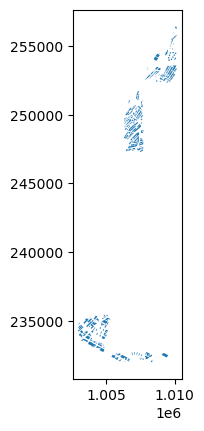

In [ ]:
gdf[(gdf["type"] == "test") & (gdf["boroname"] == "Bronx")].plot()

In [ ]:
gdf["sq_diff"] = (gdf["predicted_value"] - gdf["var"]) ** 2
gdf_by_census_tract["sq_diff_tract"] = (gdf_by_census_tract["predicted_value"] - gdf_by_census_tract["var"]) ** 2

# Compute R2 per boroname by sq_diff and sq_diff_tract
# gdf.groupby("boroname").apply(lambda x: 1 - (x["sq_diff"].sum() / ((x["var"] - x["var"].mean()) ** 2).sum()))
table = gdf_by_census_tract.groupby(["boroname", "type"]).apply(lambda x: (1 - (x["sq_diff_tract"].sum() / ((x["var"] - x["var"].mean()) ** 2).sum()), x["sq_diff_tract"].shape[0] ))

/tmp/ipykernel_1604/987586940.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = gdf_by_census_tract.groupby(["boroname", "type"]).apply(lambda x: (1 - (x["sq_diff_tract"].sum() / ((x["var"] - x["var"].mean()) ** 2).sum()), x["sq_diff_tract"].shape[0] ))


In [ ]:
table

0
boroname      type                               
Bronx         test      (-2.6054975828130247, 20)
              train      (0.4765964812833834, 72)
Brooklyn      test      (0.1570291652604333, 139)
              train     (0.7578554080428814, 620)
Manhattan     test       (0.6006065640267931, 65)
              train      (0.689397299782575, 220)
Queens        test   (-0.014487456905926788, 216)
              train       (0.84370190410025, 467)
Staten Island test      (0.30057976155106814, 36)
              train      (0.8637806377067224, 83)

In [ ]:
import pandas as pd

# 1. Convert Series to DataFrame and reset index so 'boroname' and 'type' become columns
table.name = "R2_and_n"  # Name the Series for clarity when converting to DataFrame
df = table.to_frame().reset_index()

# 2. Split the tuple column ("R2_and_n") into two distinct columns
# We use .tolist() on the column to easily create a new DataFrame structure
df[['R2', 'n']] = pd.DataFrame(df['R2_and_n'].tolist(), index=df.index)

# 3. Drop the original tuple column (optional, but cleaner)
df = df.drop(columns=['R2_and_n'])

# 4. Pivot the table
result = df.pivot(index="boroname", columns="type", values=["R2", "n"])

print(result)

                     R2                n       
type               test     train   test  train
boroname                                       
Bronx         -2.605498  0.476596   20.0   72.0
Brooklyn       0.157029  0.757855  139.0  620.0
Manhattan      0.600607  0.689397   65.0  220.0
Queens        -0.014487  0.843702  216.0  467.0
Staten Island  0.300580  0.863781   36.0   83.0


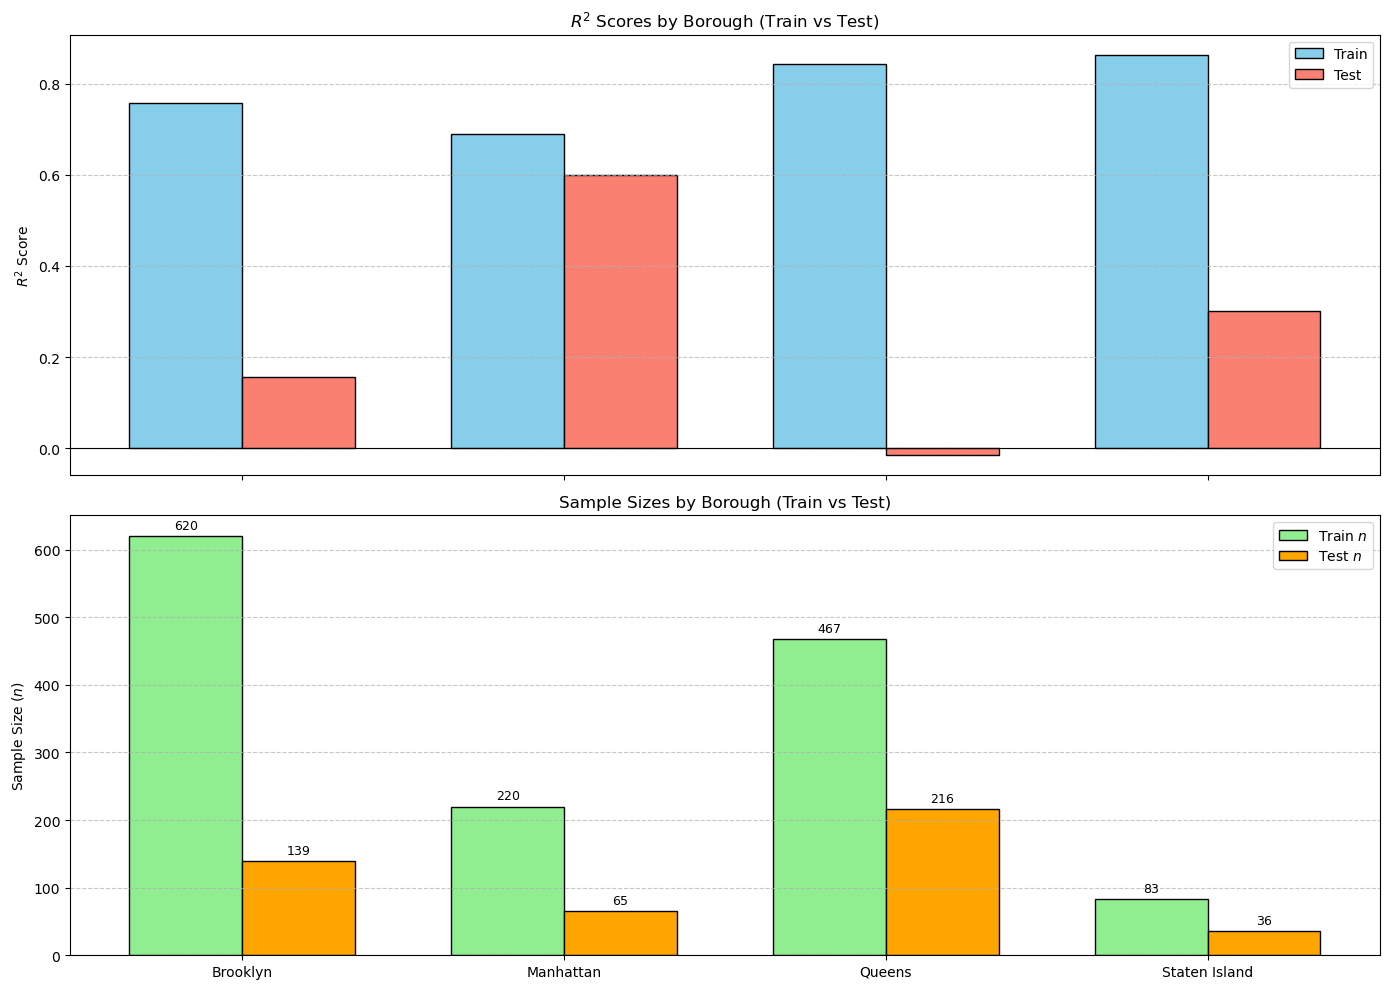

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
boroughs = ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
r2_test = [0.157029, 0.600607, -0.014487, 0.300580]
r2_train = [0.757855, 0.689397, 0.843702, 0.863781]
n_test = [139, 65, 216, 36]
n_train = [620, 220, 467, 83]

x = np.arange(len(boroughs))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1. R^2 Score Plot
ax1.bar(x - width/2, r2_train, width, label='Train', color='skyblue', edgecolor='black')
ax1.bar(x + width/2, r2_test, width, label='Test', color='salmon', edgecolor='black')

ax1.set_ylabel('$R^2$ Score')
ax1.set_title('$R^2$ Scores by Borough (Train vs Test)')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.8) # Zero line for reference

# 2. Sample Size (n) Plot
rects_n_train = ax2.bar(x - width/2, n_train, width, label='Train $n$', color='lightgreen', edgecolor='black')
rects_n_test = ax2.bar(x + width/2, n_test, width, label='Test $n$', color='orange', edgecolor='black')

ax2.set_ylabel('Sample Size ($n$)')
ax2.set_title('Sample Sizes by Borough (Train vs Test)')
ax2.set_xticks(x)
ax2.set_xticklabels(boroughs)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Helper function to add labels on top of bars
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects_n_train, ax2)
autolabel(rects_n_test, ax2)

plt.tight_layout()
plt.show()

In [ ]:
# Get the distribution of the target variable
# I want the 10 percentiles

# gdf["var"].describe()
gdf["var"].quantile([0.1 * i for i in range(1, 11)])

0.1   -1.301139
0.2   -0.767641
0.3   -0.415436
0.4   -0.110364
0.5    0.140984
0.6    0.349322
0.7    0.511249
0.8    0.779734
0.9    1.089434
1.0    2.894900
Name: var, dtype: float64

In [ ]:
from src import build_dataset

datasets, extents = build_dataset.load_satellite_datasets(year=2014, stretch=False, engine="zarr")

Loading 1 files from /mnt/e/Datasets/Imagenes Satelitales/New York City...


In [ ]:
import numpy as np
import geopandas as gpd

def get_test_area_from_file(filename = "Test_NYC_Area.parquet"):
    test = gpd.read_parquet(RAW_DATA_DIR / filename)
    print(test.crs)
    test_polygon = test.dissolve().geometry.iloc[0]
    return test_polygon

def split_train_test_polygon(gdf, test_polygon, buffer=0):
    """
    Splits the GeoDataFrame into 'train' and 'test' based on a test_polygon.
    
    Logic:
    - TEST:  Geometry is strictly INSIDE the test_polygon.
    - TRAIN: Geometry is strictly OUTSIDE the (test_polygon + buffer).
    - DROP:  Geometry overlaps the border or falls within the buffer zone.
    """
    
    # Initialize column with NaNs
    gdf["type"] = np.nan

    # 1. Identify TEST rows
    # "within" checks if the feature is fully contained inside the test polygon
    test_mask = gdf.geometry.within(test_polygon)
    gdf.loc[test_mask, "type"] = "test"

    # 2. Identify TRAIN rows
    # We buffer the test polygon to create the "exclusion zone"
    # "disjoint" checks if the feature has absolutely no overlap with the buffered zone
    exclusion_zone = test_polygon.buffer(buffer)
    train_mask = gdf.geometry.disjoint(exclusion_zone)
    gdf.loc[train_mask, "type"] = "train"

    # 3. Calculate and Print Stats
    test_size = gdf[gdf["type"] == "test"].shape[0]
    train_size = gdf[gdf["type"] == "train"].shape[0]
    invalid_size = gdf[gdf["type"].isna()].shape[0]
    total_size = gdf.shape[0]

    print(
        "",
        f"Size of test dataset: {test_size/total_size*100:.2f}% ({test_size} features)",
        f"Size of train dataset: {train_size/total_size*100:.2f}% ({train_size} features)",
        f"Deleted images due to train/test overlapping: {invalid_size/total_size*100:.2f}% ({invalid_size} features)",
        sep="\n",
    )

    return gdf

gdf = build_dataset.load_income_dataset(variable="avg_hh_inc", trim=False)
test_polygon = get_test_area_from_file()
split_train_test_polygon(gdf, test_polygon, buffer=500)

{"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "BoundCRS", "source_crs": {"type": "ProjectedCRS", "name": "unknown", "base_crs": {"name": "unknown", "datum": {"type": "GeodeticReferenceFrame", "name": "Unknown based on GRS 1980 ellipsoid using towgs84=0,0,0,0,0,0,0", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101, "id": {"authority": "EPSG", "code": 7019}}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Latitude", "abbreviation": "lat", "direction": "north", "unit": "degree"}, {"name": "Longitude", "abbreviation": "lon", "direction": "east", "unit": "degree"}]}}, "conversion": {"name": "unknown", "method": {"name": "Lambert Conic Conformal (2SP)", "id": {"authority": "EPSG", "code": 9802}}, "parameters": [{"name": "Latitude of false origin", "value": 40.1666666666667, "unit": "degree", "id": {"authority": "EPSG", "code": 8821}}, {"name": "Longitude of false origin", "value": -74, "unit": 

/tmp/ipykernel_25278/3844879608.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'test' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gdf.loc[test_mask, "type"] = "test"



Size of test dataset: 23.94% (107673 features)
Size of train dataset: 73.13% (328875 features)
Deleted images due to train/test overlapping: 2.93% (13179 features)


,capture_da,boroname,index_righ,GEOID,STATE,COUNTY,TRACT,NAME,CNTY_FIPS,avg_hh_inc,geometry,var,type
0,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1067053.173 209139.295, 1067044.762 ...",0.903605,train
1,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066993.434 211949.564, 1067030.554 ...",0.903605,train
2,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066744.615 209584.918, 1066783.937 ...",0.903605,train
3,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,"POLYGON ((1066671.441 209426.912, 1066706.044 ...",0.903605,train
4,None,Queens,74995,36081157903,36,081,157903,Census Tract 1579.03,36081,104135,"POLYGON ((1066621.379 208092.188, 1066602.7 20...",0.317018,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
457302,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914278.373 123196.517, 914236.906 12...",1.036937,train
457303,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914230.566 124269.59, 914264.523 124...",1.036937,train
457304,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((914203.412 124013.548, 914200.86 123...",1.036937,train
457305,7/25/2019-7/30/2019,Staten Island,64529,36085024401,36,085,024401,Census Tract 244.01,36085,127250,"POLYGON ((913923.046 124090.499, 913924.229 12...",1.036937,train


In [ ]:
import os
import numpy as np

folder = r"/home/abbatenicolas/data/val_datasets/val_size128_tiles1_stacked1-4"
files = os.listdir(folder)
file = files[np.random.randint(0, high=len(files))]
print(file)

test = np.load(rf"{folder}/{file}")
import matplotlib.pyplot as plt
print(test.shape)
random_int2 = np.random.randint(0, high=test.shape[0])
# Plot the numpy array as an image
plt.imshow(test[random_int2, :, :, 4:7])
plt.axis('off')  # Turn off the axis
plt.show()

NotADirectoryError: [Errno 20] Not a directory: '/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/debug_examples/effnet_v2B1_lr0.001_size384_y2016-2018-2020-2022-2024_stack1-4_transferfrom_stacked_1-4_Pooling_example_img.npy'

/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/debug_examples/effnet_v2B1_lr0.001_size384_y2016-2018-2020-2022-2024_stack1-4_transferfrom_stacked_1-4_Pooling_example_img.npy
(16, 128, 128, 8)


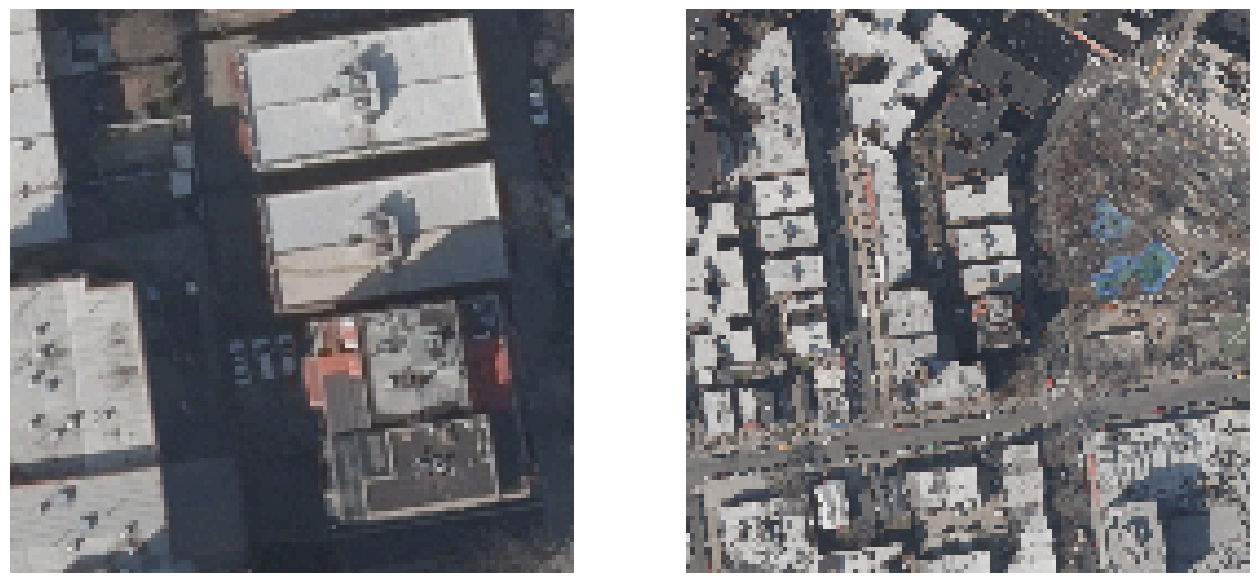

In [ ]:
import os
import numpy as np

file = r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/debug_examples/effnet_v2B1_lr0.001_size384_y2016-2018-2020-2022-2024_stack1-4_transferfrom_stacked_1-4_Pooling_example_img.npy"

print(file)

test = np.load(rf"{file}")
import matplotlib.pyplot as plt
print(test.shape)
random_int2 = np.random.randint(0, high=test.shape[0])
# Plot the numpy array as an image
fig, ax= plt.subplots(1, 2, figsize=(16, 10))
    
ax[0].imshow(test[random_int2, :, :, :3])
ax[1].imshow(test[random_int2, :, :, 4:7])

ax[0].axis('off')  # Turn off the axis
ax[1].axis('off')  # Turn off the axis
plt.show()

In [ ]:
import xarray as xr

# "E:\Datasets\Imagenes Satelitales\New York City\nyc_2022.zarr"

ds['spatial_ref'].attrs

{'crs_wkt': 'PROJCS["NAD83(2011) / New York Long Island (ftUS)",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",40.1666666666667],PARAMETER["central_meridian",-74],PARAMETER["standard_parallel_1",41.0333333333333],PARAMETER["standard_parallel_2",40.6666666666667],PARAMETER["false_easting",984250],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6539"]]',
 'semi_major_axis': 6378137.0,
 'semi_minor_axis': 6356752.314140356,
 'inverse_flattening': 298.257222101004,
 'reference_ellipsoid_name': 'GRS 1980',
 'longitude_of_prime_meridian': 0.0,
 'prime_meridian_name': 'Greenwich',
 'geo

In [ ]:
import numpy as np
import xarray as xr
from dask.diagnostics import ProgressBar
# import rioxarray # Required for the .rio accessor to export TIFFs

# 1. Open the huge Zarr lazily using Dask
# This happens instantly and uses almost zero RAM
ds = xr.open_zarr(r"/home/abbatenicolas/data/nyc_2022.zarr")

# Assume your spatial dimensions are named 'x' and 'y'
# If they are 'lon' and 'lat', change the names below accordingly.
reduction_factor = 100

# --- OPTION A: The Ultra-Fast Way (Subsampling) ---
# Grabs every 10th pixel. 
ds_small = ds.isel(x=slice(0, None, reduction_factor), 
                   y=slice(0, None, reduction_factor),
                   band=slice(0, 3))  # If you also want to subsample bands
ds_small = ds_small.sortby('y')
# --- OPTION B: The High-Quality Way (Coarsening) ---
# Un-comment this if you prefer to take the mean of 10x10 pixel blocks.
# ds_small = ds.coarsen(x=reduction_factor, y=reduction_factor, boundary="trim").mean()

# 2. Select the specific variable you want to export
# TIFF files usually hold a single variable (or a few bands). 
# Replace 'my_variable' with your actual data variable name.


# by 40x first, it should easily fit in your RAM.
data_to_export = ds_small['value'].astype('uint8')
# data_to_export['x'].attrs = {'standard_name': 'projection_x_coordinate', 'axis': 'X', 'units': 'US survey foot'}
# data_to_export['y'].attrs = {'standard_name': 'projection_y_coordinate', 'axis': 'Y', 'units': 'US survey foot'}
# data_to_export.attrs['grid_mapping'] = 'spatial_ref'
# data_to_export.encoding.clear()
# for coord in data_to_export.coords:
#     data_to_export[coord].encoding.clear()

# 3. Ensure the spatial dimensions are set for rioxarray
# rioxarray needs to know which dimensions are X and Y.
# data_to_export = data_to_export.rio.set_spatial_dims(x_dim="x", y_dim="y")

# Optional: Set a Coordinate Reference System (CRS) if it's missing
# data_to_export = data_to_export.rio.write_crs("EPSG:4326") 

# 4. Export to TIFF
# This is the step where the actual computation happens. Dask will stream 
# the chunks, downsample them, and stream them into the TIFF file.
with ProgressBar():
    data_to_export.to_zarr("/home/abbatenicolas/data/summary_very_low_res.zarr", mode="w", consolidated=False)

print("Low-resolution Zarr created successfully!")

[########################################] | 100% Completed | 228.83 s
Low-resolution Zarr created successfully!


In [ ]:
import earthpy.plot as ep

ep.plot_rgb(data_to_export)
# data_to_export

/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/earthpy/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


ImportError: libnetcdf.so.19: cannot open shared object file: No such file or directory

In [ ]:
data_to_export

<xarray.DataArray 'value' (band: 3, y: 4, x: 4)> Size: 48B
dask.array<astype, shape=(3, 4, 4), dtype=uint8, chunksize=(3, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 24B 1 2 3
    spatial_ref  int64 8B ...
  * x            (x) uint32 16B 907500 957500 1007500 1057500
  * y            (y) uint32 16B 127499 177499 227499 277499
Attributes:
    grid_mapping:  spatial_ref

In [ ]:
ds

<xarray.Dataset> Size: 2TB
Dimensions:      (band: 4, y: 320000, x: 325000)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
    spatial_ref  int64 8B ...
  * x            (x) float64 3MB 9.075e+05 9.075e+05 ... 1.07e+06 1.07e+06
  * y            (y) float64 3MB 2.775e+05 2.775e+05 ... 1.175e+05 1.175e+05
Data variables:
    value        (band, y, x) float32 2TB dask.array<chunksize=(4, 2500, 2500), meta=np.ndarray>

In [ ]:
data_to_export

<xarray.DataArray 'value' (band: 3, y: 8000, x: 8125)> Size: 780MB
dask.array<getitem, shape=(3, 8000, 8125), dtype=float32, chunksize=(3, 63, 63), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 24B 1 2 3
    spatial_ref  int64 8B ...
  * x            (x) float64 65kB 9.075e+05 9.075e+05 ... 1.07e+06 1.07e+06
  * y            (y) float64 64kB 2.775e+05 2.775e+05 ... 1.175e+05 1.175e+05

In [ ]:
from PIL import Image
import os

# List of image filenames based on your image
# (I removed the duplicates of 2010 and 2012 to make a clean progression)
image_files = [
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2010.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2012.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2016.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2018.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2020.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2022.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2024.png"
]

images = []

# Load all images into the list
for filename in image_files:
    if os.path.exists(filename):
        img = Image.open(filename)
        images.append(img)
    else:
        print(f"Warning: '{filename}' not found in the current directory.")

# Check if we successfully loaded any images
if images:
    # Save the first image as a GIF, appending the rest of the frames
    images[0].save(
        "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_progression.gif",
        save_all=True,
        append_images=images[1:], # Add the remaining images
        duration=1000,            # Show each frame for 2000 ms (2 seconds)
        loop=0                    # 0 means the GIF will loop infinitely
    )
    print("nyc_progression.gif created successfully.")
else:
    print("No images were found to create the GIF.")

nyc_progression.gif created successfully.


In [ ]:
import pandas as pd
df = pd.read_csv(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/test_10.csv")
df = df.drop_duplicates("GEOID")
df[df.sq_error < 5].sq_error.mean() / df[df.sq_error < 5].mean_prediction.var()


np.float64(1.0536314670779132)

In [ ]:
import pandas as pd

pd.read_parquet(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/nyc_buildings_with_predictions.parquet")

/home/abbatenicolas/miniconda3/envs/tf/lib/python3.9/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,capture_da,boroname,index_righ,GEOID,STATE,COUNTY,TRACT,NAME,CNTY_FIPS,avg_hh_inc,geometry,var,dataset_2022,predicted_value
0,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,b'\x01\x01\x00\x00\x00\xb5\xae\x93\xfdBH0A;1\x...,0.903605,nyc_2022.zarr,0.803223
1,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,b'\x01\x01\x00\x00\x00\xa2\xaf\xa0\xe3\x04H0A\...,0.903605,nyc_2022.zarr,0.969727
2,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,b'\x01\x01\x00\x00\x00\xcdM<\x1c\x0fG0A\x0b\x8...,0.903605,nyc_2022.zarr,0.642090
3,None,Queens,74993,36081157901,36,081,157901,Census Tract 1579.01,36081,122969,b'\x01\x01\x00\x00\x00\xf2U\xae\x86\xc4F0A\x82...,0.903605,nyc_2022.zarr,0.984375
4,None,Queens,74995,36081157903,36,081,157903,Census Tract 1579.03,36081,104135,b'\x01\x01\x00\x00\x00\x1e\xd0:i~F0A\xd9\x9b\x...,0.317018,nyc_2022.zarr,0.450684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,None,Queens,75548,36081068000,36,081,068000,Census Tract 680,36081,91513,b'\x01\x01\x00\x00\x00l\x84n\xe6\x0c\x110A\x98...,-0.076095,nyc_2022.zarr,0.072998
1016,None,Queens,65573,36081129104,36,081,129104,Census Tract 1291.04,36081,104291,b'\x01\x01\x00\x00\x00\xf7\xc4\xde\x16\xc1\x10...,0.321877,nyc_2022.zarr,0.366455
1017,None,Queens,64368,36081037600,36,081,037600,Census Tract 376,36081,103021,b'\x01\x01\x00\x00\x00\x03\xf7\x10T\xc2\x100A\...,0.282322,nyc_2022.zarr,0.239990
1018,None,Queens,73615,36081051000,36,081,051000,Census Tract 510,36081,93250,b'\x01\x01\x00\x00\x00C25o\xa1\x100A\xe0Q\x0bZ...,-0.021996,nyc_2022.zarr,0.034698


In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir "../logs"

Reusing TensorBoard on port 6006 (pid 1770), started 0:00:28 ago. (Use '!kill 1770' to kill it.)

In [ ]:
import numpy as np

links = np.load(r"/home/abbatenicolas/data/val_datasets/val_size128_tiles1_stacked1-4/valid_links.npy")
len(links)

1491

In [ ]:
import pandas as pd
#C:/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_
test = pd.read_csv(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/val_198.csv")

In [ ]:
test  = test[test.predictions!= test.predictions.mode().squeeze()] # Exclude black predictions

1 -test.drop_duplicates("GEOID").sq_error.mean() / 2.2831721200569284

np.float64(0.7065632905596728)

In [ ]:
test.predictions.mode().squeeze()

np.float64(-0.6074)

In [ ]:
test.drop_duplicates("GEOID").real_value.var()

2.2831721200569284

In [ ]:
test[test["sq_error"]>1].sort_values("sq_error", ascending=False)

,Unnamed: 0,GEOID,predictions,real_value,mean_prediction,error,sq_error
21714,21714,36061007900,-0.6895,4.860028,-0.689453,-5.549481,30.796740
21801,21801,36061019900,-1.2100,4.164807,-1.209961,-5.374768,28.888132
21540,21540,36061007001,-0.2207,4.274874,-0.220703,-4.495577,20.210213
21515,21515,36061006900,-0.4172,4.860028,0.376831,-4.483197,20.099054
21516,21516,36061006900,1.1710,4.860028,0.376831,-4.483197,20.099054
...,...,...,...,...,...,...,...
17545,17545,36005032300,0.2363,-0.217494,0.784934,1.002428,1.004862
17552,17552,36005032300,0.3853,-0.217494,0.784934,1.002428,1.004862
17542,17542,36005032300,0.1968,-0.217494,0.784934,1.002428,1.004862
17543,17543,36005032300,1.6930,-0.217494,0.784934,1.002428,1.004862


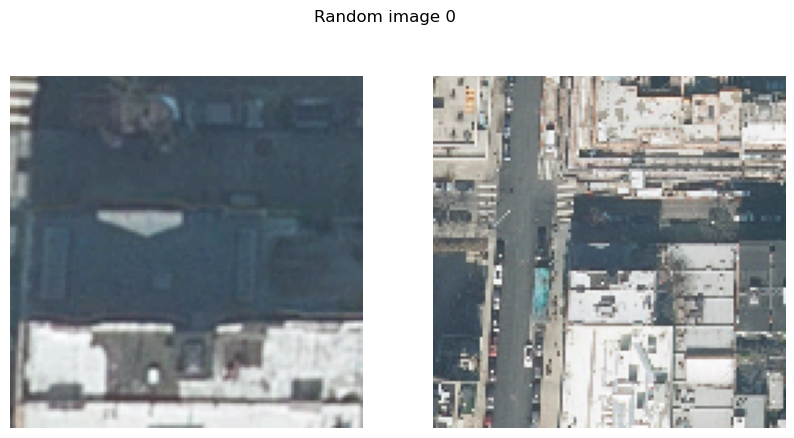

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.load

# "\\wsl.localhost\Ubuntu\home\abbatenicolas\data\val_datasets\val_size128_tiles1_stacked1-4\test_36081010400.npy"
img = np.load("/home/abbatenicolas/data/val_datasets/val_size128_tiles1_stacked1-4/test_36061007900.npy")
random_int = np.random.randint(0, high=img.shape[0])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img[random_int,..., 0:3])  # first band
ax[0].axis('off')
ax[1].imshow(img[random_int,..., 4:7])  # first band
ax[1].axis('off')
plt.suptitle(f"Random image {random_int}")
plt.show()



In [ ]:
from src import geo_utils
import pandas as pd

df_subset = pd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/train_datasets/effnet_v2S_lr0.0005_size128_y2016_stack1-4_Pooling_train_dataframe.feather")
i = 10
df_subset

,GEOID,var,type,geometry,dataset_2016
0,36061023502,-1.320342,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr
1,36005033700,0.475827,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr
2,36005011502,-2.104887,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr
3,36047083800,-0.164018,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr
4,36047041000,-0.642811,train,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...",nyc_2016.zarr
...,...,...,...,...,...
744,36085015601,1.132708,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...,nyc_2016.zarr
745,36081120701,0.316707,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr
746,36085012806,-1.258799,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr
747,36085029105,1.402892,train,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...,nyc_2016.zarr


Loading 1 files from /home/abbatenicolas/data...


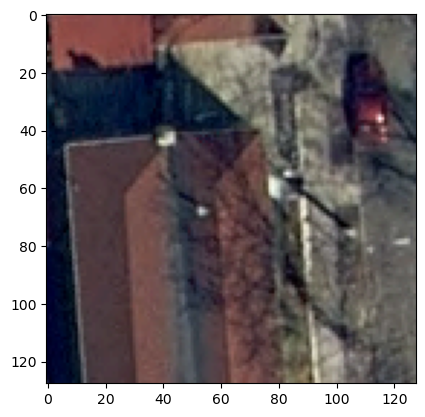

In [ ]:
from src import geo_utils, build_dataset
import geopandas as gpd
import pandas as pd
import numpy as np
primary_dataset = build_dataset.load_satellite_datasets(year=2016, stretch=False, engine="zarr")[0]
df_subset = gpd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/train_datasets/effnet_v2S_lr0.0005_size128_y2016_stack1-4_Pooling_train_dataframe.feather")
i = np.random.randint(0, len(df_subset))
batch_year = 2016
nbands = 4
stacked_images = [1, 4]
image_size = 128
resizing_size = 128
total_bands = len(stacked_images) * nbands
target_shape = (resizing_size, resizing_size, total_bands)

polygon = df_subset.iloc[i]["geometry"]
value = df_subset.iloc[i]["var"]

# Logic to get dataset
dataset_name = df_subset.iloc[i][f"dataset_{batch_year}"]
link_dataset = primary_dataset[dataset_name]

# RANDOM CROP HAPPENS HERE
image, _ = geo_utils.stacked_image_from_census_tract(
    dataset=link_dataset,
    polygon=polygon,
    img_size=image_size,
    n_bands=nbands,
    stacked_images=stacked_images,
)
image, value
image = np.transpose(image, (1, 2, 0))

plt.imshow(image[..., 0:3])  # first band


In [ ]:
def get_mini_batch_data(batch_indices, df_subset):
    indices = batch_indices
    batch_imgs = []
    batch_lbls = []
    
    # Randomly pick a year for this batch to optimize Zarr access
    batch_year = 2016
    
    total_bands = nbands * len(stacked_images)
    target_shape = (total_bands, image_size, image_size)
    
    for i in indices:
        # ... (Standard extraction logic) ...
        try:
            polygon = df_subset.iloc[i]["geometry"]
            value = df_subset.iloc[i]["var"]
            
            # Logic to get dataset
            dataset_name = df_subset.iloc[i][f"dataset_{batch_year}"]
            if not pd.isna(dataset_name):
                link_dataset = primary_dataset[dataset_name]
            else:
                link_dataset = None # (Fallback logic omitted for brevity, add back if needed)

            image = np.zeros(shape=(nbands, 0, 0))
            if link_dataset is not None:
                # RANDOM CROP HAPPENS HERE
                image, _ = geo_utils.stacked_image_from_census_tract(
                    dataset=link_dataset,
                    polygon=polygon,
                    img_size=image_size,
                    n_bands=nbands,
                    stacked_images=stacked_images,
                )
            
            if image.shape != target_shape:
                    image = np.zeros(shape=(resizing_size, resizing_size, total_bands))
                    return None  
            else:
                    image = geo_utils.process_image(image, resizing_size)
                    # NO AUGMENTATION HERE (We cache the clean image)

            batch_imgs.append(image)
            batch_lbls.append(value)

        except Exception as e:
            print(e)
            # Fail-safe
            batch_imgs.append(np.zeros((resizing_size, resizing_size, total_bands)))
            batch_lbls.append(0.0)


    return np.stack(batch_imgs).astype(np.uint8), np.stack(batch_lbls).astype(np.float32)

get_mini_batch_data(np.random.randint(0, len(df_subset), size=4), df_subset)

(array([[[[152, 156, 148, ..., 172, 168, 168],
          [152, 156, 148, ..., 188, 184, 176],
          [148, 156, 148, ..., 180, 180, 168],
          ...,
          [  4,  20,  28, ..., 196, 188, 188],
          [  4,  24,  36, ..., 196, 188, 184],
          [ 12,  28,  36, ..., 192, 184, 184]],
 
         [[152, 156, 148, ..., 112, 108, 104],
          [148, 156, 148, ..., 140, 136, 132],
          [148, 156, 144, ...,  92, 100,  88],
          ...,
          [  0,  16,  28, ..., 196, 188, 188],
          [  4,  20,  32, ..., 196, 188, 188],
          [  8,  24,  36, ..., 200, 188, 192]],
 
         [[152, 156, 148, ...,  56,  64,  68],
          [152, 160, 148, ...,  32,  40,  44],
          [152, 160, 148, ...,  60,  72,  64],
          ...,
          [  4,  16,  28, ..., 200, 188, 188],
          [  0,  16,  28, ..., 200, 192, 188],
          [ 12,  24,  36, ..., 212, 200, 200]],
 
         ...,
 
         [[112, 108,  92, ..., 112, 116,  96],
          [116, 112, 100, ..., 116, 1

In [ ]:
link_dataset

<xarray.Dataset> Size: 416GB
Dimensions:      (band: 4, y: 320000, x: 325000)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
    spatial_ref  int64 8B ...
  * x            (x) float64 3MB 9.075e+05 9.075e+05 ... 1.07e+06 1.07e+06
  * y            (y) float64 3MB 2.775e+05 2.775e+05 ... 1.175e+05 1.175e+05
Data variables:
    value        (band, y, x) uint8 416GB ...

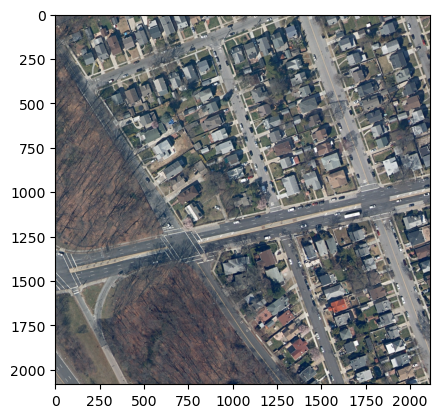

In [ ]:
import matplotlib.pyplot as plt

bounds = polygon.buffer(500).bounds
img = link_dataset.sel(y=slice(bounds[3], bounds[1]), x=slice(bounds[0], bounds[2])).value.to_numpy()
img = np.transpose(img, (1, 2, 0))

plt.imshow(img[..., :3])  # first band
plt.show()


In [ ]:
polygon

<Axes: >

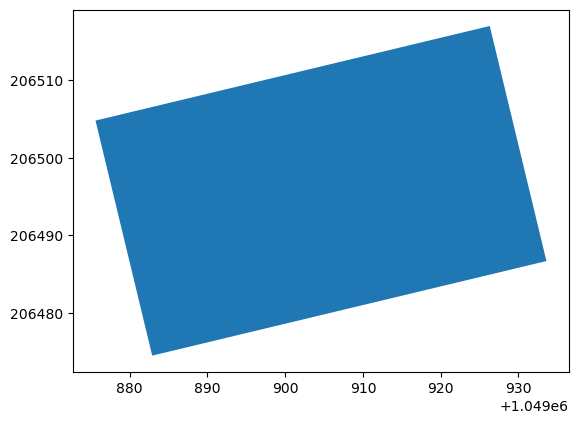

In [ ]:
gpd.GeoDataFrame(geometry=[polygon]).set_crs("EPSG:6539").plot()


In [ ]:
img.shape

(4, 2083, 2114)

In [ ]:
gpd.GeoDataFrame(geometry=[polygon]).set_crs("EPSG:6539").explore()

In [65]:
import geopandas as gpd
import pandas as pd
import numpy as np
import scipy.stats as stats

def load_and_prep(file_path, year, crs="EPSG:3857"):
    """Loads a feather file and projects it to a metric CRS for area calculations."""
    print(f"Loading {year} data...")
    # Read the feather file. Assuming it was saved as a GeoDataFrame.
    gdf = gpd.read_feather(file_path)
    
    # Ensure it is projected to a metric CRS (like Web Mercator or NY State Plane)
    # This is crucial for accurate area calculations in square meters
    if gdf.crs != crs:
        gdf = gdf.to_crs(crs)

    # Clip to NYC boundary
    NYC_boundary = gpd.read_file(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\external\NYC Borough Boundaries\Borough_Boundaries_20260131.geojson").to_crs(crs)
    gdf = gdf.clip(NYC_boundary.dissolve())

    # We only need the geoid, Geometry, Per Capita Income Estimate, and MOE
    # B19301_001E = Per Capita Income Estimate, B19301_001M = Margin of Error
    cols_to_keep = ['geoid', 'geometry', 'per_capita_income_usd', 'per_capita_income_usd_error']
    gdf = gdf[cols_to_keep].copy()
    gdf.rename(columns={col:col + f"_{year}" for col in gdf.columns if col != 'geometry'}, inplace=True)
    
    # 1. Convert MOE to Standard Error (Census uses 90% confidence level -> 1.645)
    gdf[f'SE_{year}'] = gdf[f'per_capita_income_usd_error_{year}'] / 1.645

    # 2. Take the Natural Log of Income
    gdf[f'Log_PCI_{year}'] = np.log(gdf[f'per_capita_income_usd_{year}'])
    
    # 3. Transform the Standard Error using the Delta Method: SE(ln(X)) ≈ SE(X) / X
    gdf[f'Log_SE_{year}'] = gdf[f'SE_{year}'] / gdf[f'per_capita_income_usd_{year}']
    
    # 4. Calculate City-Wide Macro Moments for the LOGGED year
    city_log_mean = gdf[f'Log_PCI_{year}'].mean()
    city_log_std = gdf[f'Log_PCI_{year}'].std()
    
    # 5. Calculate Relative Position (Z-score of Logs)
    gdf[f'Rel_Score_{year}'] = (gdf[f'Log_PCI_{year}'] - city_log_mean) / city_log_std
    
    # 6. Calculate Relative Standard Error
    gdf[f'Rel_SE_{year}'] = gdf[f'Log_SE_{year}'] / city_log_std
    
    return gdf

def spatial_align_max_overlap(target_gdf, source_gdf, target_year, source_year):
    """
    Aligns historical tracts to the modern tracts using Maximum Area Overlap.
    For every target tract, it finds the source tract that covers the most of its area.
    """
    print(f"Spatially matching {source_year} tracts to {target_year} boundaries...")
    
    # Compute the spatial intersection of both GeoDataFrames
    intersection = gpd.overlay(target_gdf, source_gdf, how='intersection', keep_geom_type=False)
    
    # Calculate the area of each overlapping polygon
    intersection['overlap_area'] = intersection.geometry.area
    
    # Sort by the target geoid and the overlap area (descending)
    intersection = intersection.sort_values(by=[f'geoid_{target_year}', 'overlap_area'], ascending=[True, False])
    
    # Keep only the source tract that has the largest overlap with the target tract
    best_match = intersection.drop_duplicates(subset=[f'geoid_{target_year}'], keep='first')
    
    # Drop geometry to return a pure DataFrame for merging, and drop the overlap area
    best_match = pd.DataFrame(best_match.drop(columns=['geometry', 'overlap_area']))
    
    return best_match

def test_significance(df, year1, year2):
    """
    Computes the Z-score and P-value for the difference between two ACS estimates.
    Formula: Z = |Est1 - Est2| / sqrt(SE1^2 + SE2^2)
    """
    print(f"Computing statistical significance: {year1} vs {year2}...")
    
    # Estimate difference
    diff = df[f'Rel_Score_{year2}'] - df[f'Rel_Score_{year1}']
    
    # Standard Error of the difference
    se_diff = np.sqrt(df[f'Rel_SE_{year2}']**2 + df[f'Rel_SE_{year1}']**2)
    
    # Z-score
    z_score = np.abs(diff) / se_diff
    
    # Two-tailed P-value
    p_value = 2 * (1 - stats.norm.cdf(z_score))
    
    # Add to dataframe
    df[f'diff_{year1}_{year2}'] = diff
    df[f'zscore_{year1}_{year2}'] = z_score
    df[f'pvalue_{year1}_{year2}'] = p_value
    
    # Boolean flag for statistical significance at 95% confidence (p < 0.05)
    df[f'significant_{year1}_{year2}'] = p_value < 0.05
    
    return df

if __name__ == "__main__":
    # 1. Define paths (Adjust these to point to your actual feather files)
    file_2013 = r"E:\Datasets\US ACS 5-year Census Tract Estimates\2013\ny_tracts_acs5_2013.feather"
    file_2018 = r"E:\Datasets\US ACS 5-year Census Tract Estimates\2018\ny_tracts_acs5_2018.feather"
    file_2024 = r"E:\Datasets\US ACS 5-year Census Tract Estimates\2024\ny_tracts_acs5_2024.feather"
    
    # 2. Load and prep data
    # We use 2024 as the base "target" geometry because it reflects the 2020 Census boundaries
    gdf_2013 = load_and_prep(file_2013, 2013)
    gdf_2024 = load_and_prep(file_2024, 2024)
    gdf_2018 = load_and_prep(file_2018, 2018)
    
    # 3. Spatially align 2013 and 2018 data to the 2024 tract boundaries
    matched_2018 = spatial_align_max_overlap(gdf_2024[['geoid_2024', 'geometry']], gdf_2018, 2024, 2018)
    matched_2013 = spatial_align_max_overlap(gdf_2024[['geoid_2024', 'geometry']], gdf_2013, 2024, 2013)
    
    # 4. Merge everything into the 2024 base GeoDataFrame
    final_gdf = gdf_2024.merge(matched_2018, on='geoid_2024', how='left')
    final_gdf = final_gdf.merge(matched_2013, on='geoid_2024', how='left')
    
    # 5. Run the Statistical Tests
    # Compare 2013 to 2018
    final_gdf = test_significance(final_gdf, 2013, 2018)
    
    # Compare 2018 to 2024
    final_gdf = test_significance(final_gdf, 2018, 2024)
    
    # Compare 2013 to 2024 (Full Decade)
    final_gdf = test_significance(final_gdf, 2013, 2024)
    
    # 6. Create the Valid Structural Change Indicator (Filtering out Yo-Yos)
    print("Applying structural trend filter (removing transient 'yo-yo' shocks)...")
    
    # Extract significance flags
    sig_13_18 = final_gdf['significant_2013_2018']
    sig_18_23 = final_gdf['significant_2018_2024']
    sig_13_23 = final_gdf['significant_2013_2024']
    
    # Extract the difference values to check the direction of the change
    diff_13_18 = final_gdf['diff_2013_2018']
    diff_18_23 = final_gdf['diff_2018_2024']
    
    # A "Yo-Yo" tract is significant in both periods, but the direction of change reverses
    # (e.g., positive jump in 2018, negative drop in 2024)
    is_yo_yo = sig_13_18 & sig_18_23 & (np.sign(diff_13_18) != np.sign(diff_18_23))
    final_gdf['is_yo_yo'] = is_yo_yo
    
    # The tract has a valid change if ANY of the three periods are significant, 
    # AND it is NOT a yo-yo.
    any_significant = sig_13_18 | sig_18_23 | sig_13_23
    final_gdf['Valid_Structural_Change'] = any_significant & ~is_yo_yo
    

    print("Computing Inverse-Variance Weighted Mean for stable tracts...")
    # A tiny epsilon is added to avoid DivisionByZero errors just in case 
    # the Census reports an MOE of exactly 0 for any specific tract.
    eps = 1e-9 

    # Step A: Calculate the weights (Inverse of the Variance)
    # Variance is simply the Standard Error squared.
    w_13 = 1 / (final_gdf['Rel_SE_2013']**2 + eps)
    w_18 = 1 / (final_gdf['Rel_SE_2018']**2 + eps)
    w_24 = 1 / (final_gdf['Rel_SE_2024']**2 + eps)

    # Step B: Calculate the sum of weights
    sum_w = w_13 + w_18 + w_24

    # Step C: Calculate the Weighted Mean
    final_gdf['Weighted_Stable_Score'] = (
        (w_13 * final_gdf['Rel_Score_2013']) + 
        (w_18 * final_gdf['Rel_Score_2018']) + 
        (w_24 * final_gdf['Rel_Score_2024'])
    ) / sum_w

    # Step D: Construct the Final Training Labels for the Siamese Network
    # If the tract actually underwent structural change -> Use the specific year's score
    # If the tract was stable -> Overwrite with the smoothed Weighted Mean
    for year in [2013, 2018, 2024]:
        final_gdf[f'Training_Label_{year}'] = np.where(
            final_gdf['Valid_Structural_Change'] == True,
            final_gdf[f'Rel_Score_{year}'],      # Keep the real, changing trajectory
            final_gdf['Weighted_Stable_Score']   # Lock it to the smoothed structural baseline
        )
        
    print("Training labels successfully assigned!")

    # Optional: Print out how many tracts were filtered out for your records
    num_yo_yo = is_yo_yo.sum()
    print(f"Filtered out {num_yo_yo} tracts due to reversing transient shocks (Yo-Yo effect).")
    print(f"Final count of tracts with valid structural change: {final_gdf['Valid_Structural_Change'].sum()} out of {len(final_gdf)} total tracts.")

    # 7. Save out the panel dataset
    output_name = r"E:\Datasets\US ACS 5-year Census Tract Estimates\ny_tracts_panel_2013_2024.feather"
    final_gdf.to_feather(output_name)
    print(f"Panel dataset successfully created and saved to {output_name}!")

    # 6. Save out the panel dataset
    # output_name = "ny_tracts_panel_2013_2024.feather"
    # final_gdf.to_feather(output_name)
    # print(f"Panel dataset successfully created and saved to {output_name}!")

Loading 2013 data...
Loading 2024 data...
Loading 2018 data...
Spatially matching 2018 tracts to 2024 boundaries...
Spatially matching 2013 tracts to 2024 boundaries...
Computing statistical significance: 2013 vs 2018...
Computing statistical significance: 2018 vs 2024...
Computing statistical significance: 2013 vs 2024...
Applying structural trend filter (removing transient 'yo-yo' shocks)...
Computing Inverse-Variance Weighted Mean for stable tracts...
Training labels successfully assigned!
Filtered out 39 tracts due to reversing transient shocks (Yo-Yo effect).
Final count of tracts with valid structural change: 669 out of 2356 total tracts.
Panel dataset successfully created and saved to E:\Datasets\US ACS 5-year Census Tract Estimates\ny_tracts_panel_2013_2024.feather!


                Rel_Score_2013  Rel_Score_2018  Rel_Score_2024
Rel_Score_2013        1.000000        0.908335        0.893685
Rel_Score_2018        0.908335        1.000000        0.888651
Rel_Score_2024        0.893685        0.888651        1.000000
                Rel_Score_2013  Rel_Score_2018  Rel_Score_2024
Rel_Score_2013        1.000000        0.884136        0.764185
Rel_Score_2018        0.884136        1.000000        0.803381
Rel_Score_2024        0.764185        0.803381        1.000000


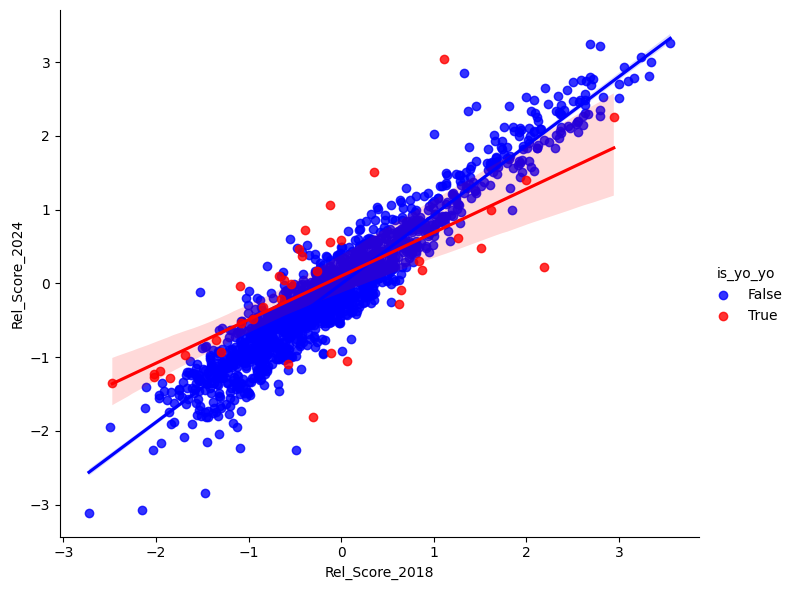

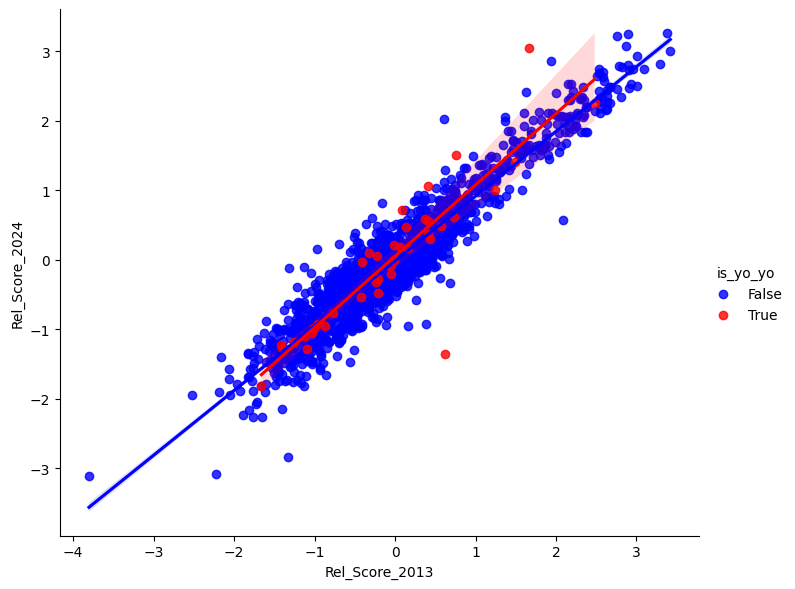

In [63]:
import seaborn as sns
sns.lmplot(data=final_gdf[final_gdf['Valid_Structural_Change'] == False], x='Rel_Score_2018', y='Rel_Score_2024', hue='is_yo_yo', palette={True: 'red', False: 'blue'}, height=6, aspect=1.2)

sns.lmplot(data=final_gdf[final_gdf['Valid_Structural_Change'] == False], x='Rel_Score_2013', y='Rel_Score_2024', hue='is_yo_yo', palette={True: 'red', False: 'blue'}, height=6, aspect=1.2)

r2 = final_gdf[final_gdf['Valid_Structural_Change'] == False][['Rel_Score_2013','Rel_Score_2018','Rel_Score_2024']].corr() **2 
print(r2)
r2 = final_gdf[['Rel_Score_2013','Rel_Score_2018','Rel_Score_2024']].corr() **2 
print(r2)

# final_gdf[final_gdf['Valid_Structural_Change'] == False][['Rel_Score_2013','Rel_Score_2024']]

In [39]:
    print(f"Final count of tracts with valid structural change: {final_gdf['Valid_Structural_Change'].sum()} out of {len(final_gdf)} total tracts.")


Final count of tracts with valid structural change: 504 out of 2356 total tracts.


In [31]:
output_name = r"E:\Datasets\US ACS 5-year Census Tract Estimates\ny_tracts_panel_2013_2024.feather"
final_gdf.to_feather(output_name)
print(f"Panel dataset successfully created and saved to {output_name}!")

Panel dataset successfully created and saved to E:\Datasets\US ACS 5-year Census Tract Estimates\ny_tracts_panel_2013_2024.feather!


<Axes: >

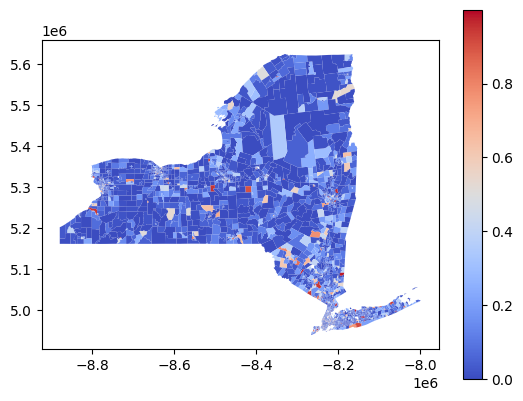